# Unconstrained Backtest: TS Momentum in Cryptocurrencies

We will run a simple unconstrained backtest to assess whether 4 of the larger coins (BTC, ETH, ADA, BNB) show time-series momentum. In other words, if they have done well recently, do they tend to continue to do well? The flow of events will be as follow:

1. Compute returns for these coins (BTC, ETH, ADA, BNB) since 2016.
2. The signal on each day for each coin will be: 
$$
\frac{\sqrt{10} * (\bar{ret}_{10 days} - \bar{ret}_{365 days})}{\sigma_{365 days}}
$$
You can think of this as the z-score of the past 10 day returns, and it tells us if a coin is doing better than it usually does. Technical note: we multiply by sqrt(10) here because the stdev is calculated on daily data but we want to "z-score" the average 10 day returns.

3. The signal from (2) will have extreme values. Pass them through a tanh function to curtail these. These are your final daily portfolio weights.
4. Compute the returns to the weights from (3). 
5. Compute the Sharpe for the given strategies and plot the cumulative returns for each cryptocurrency.
6. Understand how correlated are the timing strategies with the underlying assets.

In [10]:
import yfinance as yf 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

#### 1. Load & Prepare Cryptocurrency Price Data

We download **daily adjusted close prices** for four major cryptocurrencies:
- **BTC** (Bitcoin)
- **ETH** (Ethereum)
- **ADA** (Cardano)
- **BNB** (Binance Coin)

**Time period**: `2016-01-01` to present  
**Source**: Yahoo Finance (`yfinance`)  
**Returns**: Simple daily returns from **adjusted close**:
$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

In [2]:
data = yf.download(['ADA-USD','BNB-USD','BTC-USD','ETH-USD'],'2016-1-1')['Close']
# Compute the daily returns
rets = data / data.shift() - 1
# OR using pandas built-in function
rets = data.pct_change()

[*********************100%***********************]  4 of 4 completed


#### 2. Construct the Time-Series Momentum Signal

For each coin and each day \( t \), the momentum signal is defined as:

$$
S_t = 
\
\sqrt{10} \times 
\frac{
\bar{R}_{t,10} - \bar{R}_{t,365}} {\sigma_{R_{t,365}}}
$$

Where:
- $\bar{R}_{t,10}$: **Mean of the past 10 daily returns** (excluding today)
- $\bar{R}_{t,365}$: **Mean of the past 365 daily returns**
- $\sigma_{t,365}$: **Standard deviation of daily returns over the past 365 days**

---

Why $\sqrt{10}$? We compare:
- A **10-day cumulative return** ≈ $\sqrt{10} \times$ daily return
- To a **daily volatility** estimate

To make the ratio **scale-consistent** (i.e., a true *z-score*), we **scale the numerator** by $\sqrt{10}$:

$$
\frac{10 \times \bar{R}_{t,10}}{\sigma_{t,365}}
\quad \text{vs.} \quad
\frac{\text{10-day total return}}{\text{10-day vol}} \approx \frac{10 \times \bar{r}}{\sqrt{10} \times \sigma} \propto \sqrt{10} \times \bar{r}/\sigma
$$

In [6]:
# Compute portfolios and strategy returns
# --- 1. Raw momentum signal ---
port = (np.sqrt(10)*(rets.rolling(10,min_periods=1).mean() - rets.rolling(365,min_periods=10).mean())) / rets.rolling(365,min_periods=10).std()

# --- 2. Apply tanh to bound positions in [-1, 1] ---
port = np.tanh(port)

# --- 3. Strategy returns: use YESTERDAY's signal (no lookahead) ---
strat_ret = port.shift()*rets # Apply the shift to avoid lookahead bias
print("Strategy Sharpe Ratio:", strat_ret.mean()/strat_ret.std()*np.sqrt(365))
print("\nStrategy Returns ")
strat_ret.tail()

Strategy Sharpe Ratio: Ticker
ADA-USD    0.579692
BNB-USD    0.780703
BTC-USD    0.575632
ETH-USD    0.690704
dtype: float64

Strategy Returns 


Ticker,ADA-USD,BNB-USD,BTC-USD,ETH-USD
Date,,,,
2026-03-13,-0.001875,0.001162,0.002686,0.001316
2026-03-14,-0.001972,0.000961,0.001856,0.000796
2026-03-15,-0.004595,-0.001455,-0.004955,-0.006659
2026-03-16,0.013738,0.003222,0.011300,0.025863
2026-03-17,-0.009338,-0.011198,-0.008497,-0.009332


We can now plot the strategy cumulative returns

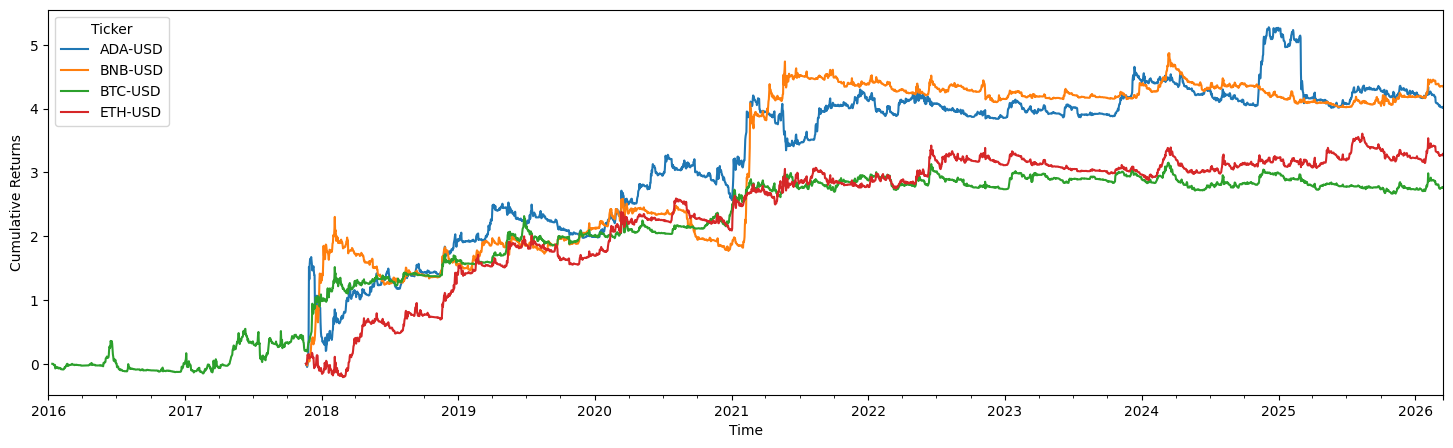

In [8]:
strat_ret.cumsum().plot()
plt.xlabel('Time')
plt.ylabel('Cumulative Returns')
plt.gcf().set_size_inches(18, 5) # Increase the size of the plot for better visibility
plt.show()


Let us also compute the performance metrics for the strategy across all 4 cryptocurrencies

In [12]:
def performance_metrics(returns_df):
  metrics = {}
  metrics['Total Return (%)'] = (returns_df + 1).prod() - 1
  metrics['Annualized Return'] = returns_df.mean() * 365
  metrics['Annualized Volatility'] = returns_df.std() * np.sqrt(365)
  metrics['Sharpe Ratio'] = metrics['Annualized Return'] / metrics['Annualized Volatility']
  metrics['Max Drawdown'] = (returns_df.cumsum() - returns_df.cumsum().cummax()).min()
  metrics['Calmar Ratio'] = metrics['Annualized Return'] / abs(metrics['Max Drawdown'])
  metrics['Sortino Ratio'] = metrics['Annualized Return'] / (returns_df[returns_df < 0].std() * np.sqrt(365))
  metrics['Information Ratio'] = metrics['Annualized Return'] / (returns_df - returns_df.mean()).std() * np.sqrt(365)
  return pd.Series(metrics)

# Store the performance metrics for each column in strat_ret into a dataframe
perf_df = pd.DataFrame({col: performance_metrics(strat_ret[col]) for col in strat_ret.columns}).T
perf_df  

,Total Return (%),Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Sortino Ratio,Information Ratio
ADA-USD,2.439730,0.482575,0.832469,0.579692,-1.472123,0.327809,0.753692,211.587473
BNB-USD,12.392677,0.521755,0.668314,0.780703,-1.063917,0.490410,1.129460,284.956731
BTC-USD,4.146650,0.271192,0.471121,0.575632,-0.520707,0.520816,0.719407,210.105782
ETH-USD,5.883773,0.394238,0.570778,0.690704,-0.535341,0.736424,0.894872,252.106819


Following that, we can print the strategy's correlation with the underlying assets

In [13]:
strat_ret.corrwith(rets)

Ticker
ADA-USD    0.064395
BNB-USD    0.140573
BTC-USD   -0.131943
ETH-USD   -0.159493
dtype: float64

As we can see from the above, they are fairly lowly correlated, suggesting we could enhance a buy and hold strategy with TS momentum